# Pythia EFPs with NTK 

Compares the EFP covariance eigenspectrum for two processes at the same center-of-mass energy (sqrt(s) = mZ = 91.188 GeV):
- **e+e- → Z → qqbar** (light quarks u, d, s)
- **e+e- → H → gg** with mH = mZ (gluon jets)

Events are generated with Pythia8. EFPs are computed with [EnergyFlow](https://energyflow.network) package.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import energyflow as ef
from energyflow.utils import gen_massless_phase_space
from energyflow import EFPSet
import os
import time
from RegressFunctions import *
from RestrictedEFPs import efps_chunked
from PhysicsFunctions import *

os.makedirs('figures', exist_ok=True)

## Load Pythia Events

Text format: one particle per line (`E px py pz`), blank line between events.

In [3]:
#########################################################
### Load events from my Pythia simulation 
#########################################################
def load_events(filepath):
    events, current = [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line:
                current.append([float(x) for x in line.split()])
            elif current:
                events.append(np.array(current))
                current = []
    if current:
        events.append(np.array(current))
    return events


Zqq_events = load_events('data/Zqq_events.txt')
Hgg_events = load_events('data/Hgg_events.txt')

mults_Z = [len(e) for e in Zqq_events]
mults_H = [len(e) for e in Hgg_events]
print(f'Z->qqbar: {len(Zqq_events)} events, avg multiplicity {np.mean(mults_Z):.1f} +/- {np.std(mults_Z):.1f}')
print(f'H->gg:    {len(Hgg_events)} events, avg multiplicity {np.mean(mults_H):.1f} +/- {np.std(mults_H):.1f}')


#########################################################
### Load events from zqq_splittings folder 
#########################################################
def load_splittings(k, folder='data/zqq_splittings'):
    """Z->qqbar partons after the k-th shower branching.
    Returns array (N_k, 2+k, 4) with columns (E, px, py, pz)."""
    return np.load(f'{folder}/splittings_{k}.npy').astype(np.float64)

Zqq_events_1 = load_splittings(1)   # 3 partons
Zqq_events_2 = load_splittings(2)   # 4 partons
Zqq_events_3 = load_splittings(3)   # 5 partons
Zqq_events_4 = load_splittings(4)   # 6 partons

for k, ev in enumerate([Zqq_events_1, Zqq_events_2, Zqq_events_3, Zqq_events_4], start=1):
    print(f'Z->qqbar, {k} splitting(s): {ev.shape[0]} events, {ev.shape[1]} partons each')

Z->qqbar: 100000 events, avg multiplicity 12.4 +/- 4.2
H->gg:    100000 events, avg multiplicity 19.9 +/- 5.2
Z->qqbar, 1 splitting(s): 99387 events, 3 partons each
Z->qqbar, 2 splitting(s): 98800 events, 4 partons each
Z->qqbar, 3 splitting(s): 96813 events, 5 partons each
Z->qqbar, 4 splitting(s): 93358 events, 6 partons each


In [4]:
#### Uniform Phase Space ####

NEvents=100_000
uniform_N3 = gen_massless_phase_space(NEvents,3,energy=1.0)
uniform_N4 = gen_massless_phase_space(NEvents,4,energy=1.0)
uniform_N5 = gen_massless_phase_space(NEvents,5,energy=1.0)
uniform_N7 = gen_massless_phase_space(NEvents,7,energy=1.0)
uniform_N10 = gen_massless_phase_space(NEvents,10,energy=1.0)

# efpset = EFPSet(('d<=', 6), measure='eeefm', beta=2,coords='epxpypz')

## Load Features, Compute Covariances, Eigenspectra

In [5]:
labels = {'u3': 'uniform $N=3$', 'u4': 'uniform $N=4$', 'u5': 'uniform $N=5$', 'u7': 'uniform $N=7$', 'u10': 'uniform $N=10$',
          'Z': r'$Z\to q\bar q$', 'H': r'$H\to gg$',
          'Z1': r'$Z\to q\bar q$, 1 splitting', 'Z2': r'$Z\to q\bar q$, 2 splittings',
          'Z3': r'$Z\to q\bar q$, 3 splittings', 'Z4': r'$Z\to q\bar q$, 4 splittings'}

In [6]:
#########################################################
### Load features (computed in make_features.ipynb)
#########################################################
F = np.load('features/EFPs_restricted_d15.npz')
EFP_sets = {k: F[k] for k in F.files if k != 'dmax'}      # keys: u3, u4, u5, u7, u10, Z1..Z4
SIJ_sets = dict(np.load('features/SIJ.npz'))              # same keys, same events
print('EFP:', {k: v.shape for k, v in EFP_sets.items()})
print('SIJ:', {k: v.shape for k, v in SIJ_sets.items()})

EFP: {'u3': (100000, 109), 'u4': (100000, 109), 'u5': (100000, 109), 'u7': (100000, 109), 'u10': (100000, 109), 'Z1': (99387, 109), 'Z2': (98800, 109), 'Z3': (96813, 109), 'Z4': (93358, 109)}
SIJ: {'u3': (100000, 3), 'u4': (100000, 6), 'u5': (100000, 10), 'u7': (100000, 21), 'u10': (100000, 45), 'Z1': (99387, 3), 'Z2': (98800, 6), 'Z3': (96813, 10), 'Z4': (93358, 15)}


In [7]:
###################################
### Compute Covariance Matrices ###
###################################
EFPs_covs = {name: np.cov(X.T) for name, X in EFP_sets.items()}
SIJs_covs = {name: np.cov(X.T) for name, X in SIJ_sets.items()}
print(f"Covariance matrix shape: {EFPs_covs['Z1'].shape}")

Covariance matrix shape: (109, 109)


In [8]:
########################
### Diagonalize ...  ###
########################
def cov_eigvals(C):
    """Eigenvalues of a covariance matrix, largest first, negatives clipped to 0."""
    return np.clip(np.linalg.eigvalsh(C)[::-1], 0, None)

EFPs_evals = {name: cov_eigvals(C) for name, C in EFPs_covs.items()}
SIJs_evals = {name: cov_eigvals(C) for name, C in SIJs_covs.items()}

for tag, evals in [('EFP', EFPs_evals), ('s_ij', SIJs_evals)]:
    for name, ev in evals.items():
        print(f'{tag:>4} {labels[name]:>22}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')

 EFP          uniform $N=3$: largest = 9.9205e+00, smallest = 0.0000e+00
 EFP          uniform $N=4$: largest = 5.4560e+00, smallest = 0.0000e+00
 EFP          uniform $N=5$: largest = 3.2320e+00, smallest = 0.0000e+00
 EFP          uniform $N=7$: largest = 1.4268e+00, smallest = 0.0000e+00
 EFP         uniform $N=10$: largest = 6.0942e-01, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, 1 splitting: largest = 6.9500e+00, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, 2 splittings: largest = 6.9625e+00, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, 3 splittings: largest = 6.8162e+00, smallest = 0.0000e+00
 EFP $Z\to q\bar q$, 4 splittings: largest = 6.6957e+00, smallest = 0.0000e+00
s_ij          uniform $N=3$: largest = 3.0862e-02, smallest = 0.0000e+00
s_ij          uniform $N=4$: largest = 1.7678e-02, smallest = 1.8583e-18
s_ij          uniform $N=5$: largest = 1.1042e-02, smallest = 1.0293e-20
s_ij          uniform $N=7$: largest = 5.1886e-03, smallest = 1.4546e-20
s_ij         uniform $N=10$:

## Plot Spectra

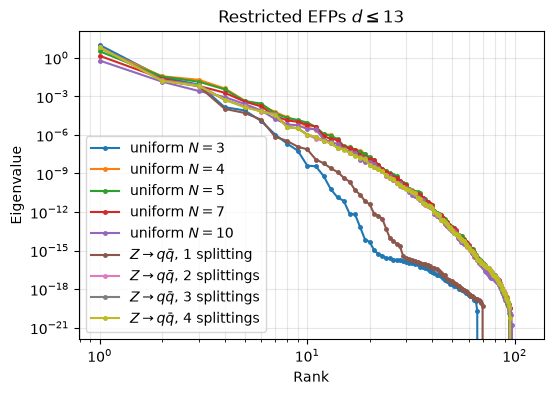

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in EFPs_evals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=5, label=labels[name])
ax.set_xlabel('Rank')
ax.set_ylabel('Eigenvalue')
ax.legend()
ax.set_title(r'Restricted EFPs $d\leq 13$')
ax.grid(True, which='both', alpha=0.3)

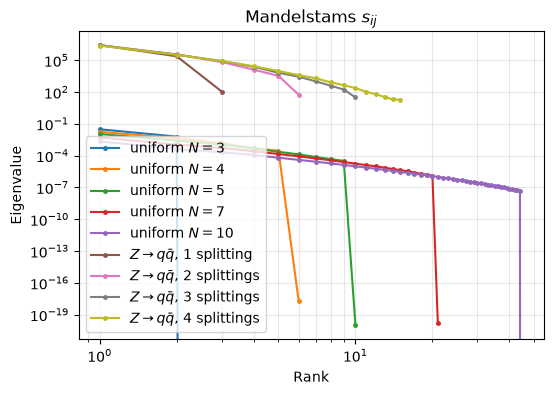

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in SIJs_evals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=5, label=labels[name])
ax.set_xlabel('Rank')
ax.set_ylabel('Eigenvalue')
ax.legend()
ax.set_title(r'Mandelstams $s_{ij}$')
ax.grid(True, which='both', alpha=0.3)

## NTK Spectra 

In [ ]:
def prep1(Z):   # standardize, append 1, unit-normalize (keeps dimension)
    Z = (Z - Z.mean(0)) / Z.std(0); Z = np.hstack([Z, np.ones((len(Z), 1))])
    return Z / np.linalg.norm(Z, axis=1, keepdims=True)

def alpha(ev, lo=50, hi=1000):
    tail = np.cumsum(ev[::-1])[::-1]; k = np.arange(1, len(tail)+1)
    return 1 - np.polyfit(np.log(k[lo:hi]), np.log(tail[lo:hi]), 1)[0]

def alpha_eig(ev, lo=20, hi=400):
    k = np.arange(1, len(ev)+1)
    return -np.polyfit(np.log(k[lo:hi]), np.log(ev[lo:hi]), 1)[0]

In [12]:
## NTK spectra, old method: full eigvalsh via kernel_spectrum on M events
M = 10_000
keys = ['u3', 'u4', 'u5', 'u7', 'u10', 'Z1', 'Z2', 'Z3']
NTK_EFP_dense, NTK_SIJ_dense = {}, {}
for key in keys:
    t0 = time.time()
    X = EFP_sets[key][:M]; X = X[:, X.std(0) > 1e-8*X.std(0).max()]
    NTK_EFP_dense[key] = kernel_spectrum(prep1(X), kernel="NTK", M=M)
    NTK_SIJ_dense[key] = kernel_spectrum(prep1(SIJ_sets[key][:M]), kernel="NTK", M=M)
    print(f'{labels[key]:>22}:  EFP α = {alpha_eig(NTK_EFP_dense[key], 200, 950):.2f}   s_ij α = {alpha_eig(NTK_SIJ_dense[key], 200, 950):.2f}   ({time.time() - t0:.0f} s)')

         uniform $N=3$:  EFP α = 1.50   s_ij α = 1.48   (29 s)
         uniform $N=4$:  EFP α = 1.23   s_ij α = 1.20   (29 s)
         uniform $N=5$:  EFP α = 1.20   s_ij α = 1.14   (29 s)
         uniform $N=7$:  EFP α = 1.18   s_ij α = 1.21   (29 s)
        uniform $N=10$:  EFP α = 1.17   s_ij α = 1.35   (29 s)
$Z\to q\bar q$, 1 splitting:  EFP α = 1.48   s_ij α = 1.45   (29 s)
$Z\to q\bar q$, 2 splittings:  EFP α = 1.21   s_ij α = 1.20   (29 s)
$Z\to q\bar q$, 3 splittings:  EFP α = 1.19   s_ij α = 1.14   (29 s)


$s_{ij}$ inp  u3  d=2  expect 1.500  got 1.479
$s_{ij}$ inp  u4  d=5  expect 1.200  got 1.205
$s_{ij}$ inp  u5  d=8  expect 1.125  got 1.144
$s_{ij}$ inp  Z1  d=2  expect 1.500  got 1.454
$s_{ij}$ inp  Z2  d=5  expect 1.200  got 1.203
$s_{ij}$ inp  Z3  d=8  expect 1.125  got 1.144
restricted E  u3  d=2  expect 1.500  got 1.498
restricted E  u4  d=5  expect 1.200  got 1.233
restricted E  u5  d=8  expect 1.125  got 1.199
restricted E  Z1  d=2  expect 1.500  got 1.479
restricted E  Z2  d=5  expect 1.200  got 1.207
restricted E  Z3  d=8  expect 1.125  got 1.187


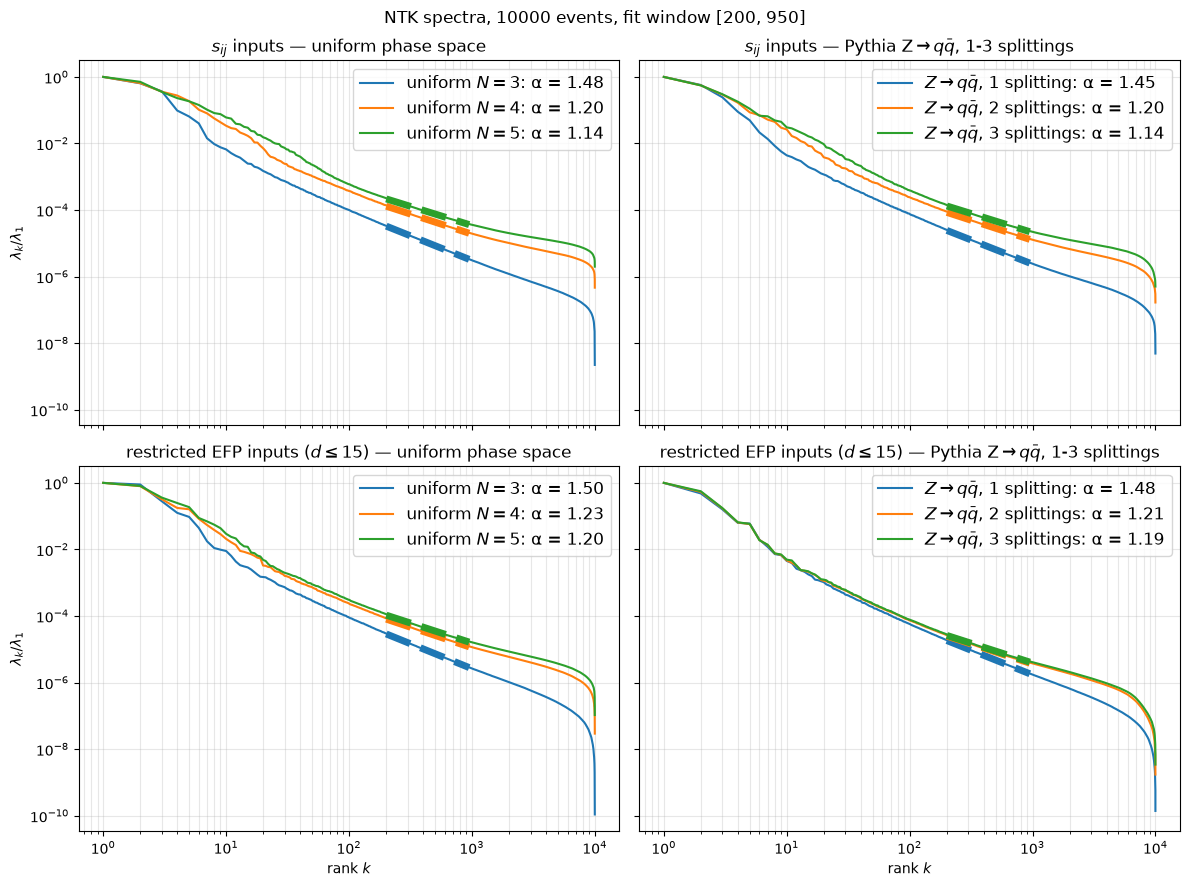

In [14]:
## 2x2: rows = input features, cols = event type; dashed = k^{-(1+1/d)} with d = 3N-7
lo, hi = 200, 950
cols = {'uniform phase space': ['u3', 'u4', 'u5'], r'Pythia Z$\to q\bar q$, 1-3 splittings': ['Z1', 'Z2', 'Z3']}
rows = {r'$s_{ij}$ inputs': NTK_SIJ_dense, r'restricted EFP inputs ($d\leq 15$)': NTK_EFP_dense}

fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
for i, (rname, L) in enumerate(rows.items()):
    for j, (cname, keys) in enumerate(cols.items()):
        ax = axs[i, j]
        for key in keys:
            lam = L[key]; 
            k = np.arange(1, len(lam) + 1)
            N = int(key[1:]) if key[0] == 'u' else int(key[1:]) + 2; 
            d = 3*N - 7
            a, b = np.polyfit(np.log(k[lo:hi]), np.log(lam[lo:hi]), 1)  
            print(f'{rname[:12]:<12} {key:>3}  d={d:<2d} expect {1 + 1/d:.3f}  got {-a:.3f}')
            # line, = ax.loglog(k, lam/lam[0], label=f'{labels[key]} (d={d}): α = {alpha_eig(lam, lo, hi):.2f}, expect {1 + 1/d:.2f}')
            line, = ax.loglog(k, lam/lam[0], label=f'{labels[key]}: α = {-a:.2f}')
            ax.loglog(k[lo:hi], np.exp(b)*k[lo:hi]**a/lam[0], '--', color=line.get_color(), lw=5)
        ax.set_title(f'{rname} — {cname}'); 
        ax.legend(fontsize=12); 
        ax.grid(True, which='both', alpha=0.3)
for ax in axs[1]: ax.set_xlabel('rank $k$')
for ax in axs[:, 0]: ax.set_ylabel(r'$\lambda_k/\lambda_1$')
fig.suptitle(f'NTK spectra, {M} events, fit window [{lo}, {hi}]')
fig.tight_layout();

In [29]:
## NTK spectra on every feature set (Lanczos: top k_top eigenvalues of K/n, n_ev events, identical settings everywhere)
n_ev, k_top, chunk = 10_000, 1000, 5000
keys = ['u3', 'u4', 'u5', 'u7', 'u10', 'Z1', 'Z2', 'Z3']
NTK_EFP_eigvals, NTK_SIJ_eigvals = {}, {}
for key in keys:
    t0 = time.time()
    X = EFP_sets[key][:n_ev]; 
    X = X[:, X.std(0) > 1e-8*X.std(0).max()]            # drop constant columns, if any
    NTK_EFP_eigvals[key] = kernel_spectrum_lanczos(prep1(X), k=k_top, chunk=chunk)
    NTK_SIJ_eigvals[key] = kernel_spectrum_lanczos(prep1(SIJ_sets[key][:n_ev]), k=k_top, chunk=chunk)
    print(f'{labels[key]:>22}:  EFP α = {alpha_eig(NTK_EFP_eigvals[key], 200, 950):.2f}   s_ij α = {alpha_eig(NTK_SIJ_eigvals[key], 200, 950):.2f}   ({time.time() - t0:.0f} s)')
    np.savez('features/NTK_eigvals.npz', **{f'EFP_{k}': v for k, v in NTK_EFP_eigvals.items()}, **{f'SIJ_{k}': v for k, v in NTK_SIJ_eigvals.items()})

         uniform $N=3$:  EFP α = 1.50   s_ij α = 1.48   (243 s)
         uniform $N=4$:  EFP α = 1.23   s_ij α = 1.20   (285 s)
         uniform $N=5$:  EFP α = 1.20   s_ij α = 1.14   (320 s)
         uniform $N=7$:  EFP α = 1.18   s_ij α = 1.21   (323 s)
        uniform $N=10$:  EFP α = 1.17   s_ij α = 1.35   (298 s)
$Z\to q\bar q$, 1 splitting:  EFP α = 1.48   s_ij α = 1.45   (242 s)
$Z\to q\bar q$, 2 splittings:  EFP α = 1.21   s_ij α = 1.20   (317 s)
$Z\to q\bar q$, 3 splittings:  EFP α = 1.19   s_ij α = 1.14   (320 s)


$s_{ij}$ inp  u3  d=2  expect 1.500  got 1.479
$s_{ij}$ inp  u4  d=5  expect 1.200  got 1.205
$s_{ij}$ inp  u5  d=8  expect 1.125  got 1.144
$s_{ij}$ inp  Z1  d=2  expect 1.500  got 1.454
$s_{ij}$ inp  Z2  d=5  expect 1.200  got 1.203
$s_{ij}$ inp  Z3  d=8  expect 1.125  got 1.144
restricted E  u3  d=2  expect 1.500  got 1.498
restricted E  u4  d=5  expect 1.200  got 1.233
restricted E  u5  d=8  expect 1.125  got 1.199
restricted E  Z1  d=2  expect 1.500  got 1.479
restricted E  Z2  d=5  expect 1.200  got 1.207
restricted E  Z3  d=8  expect 1.125  got 1.187


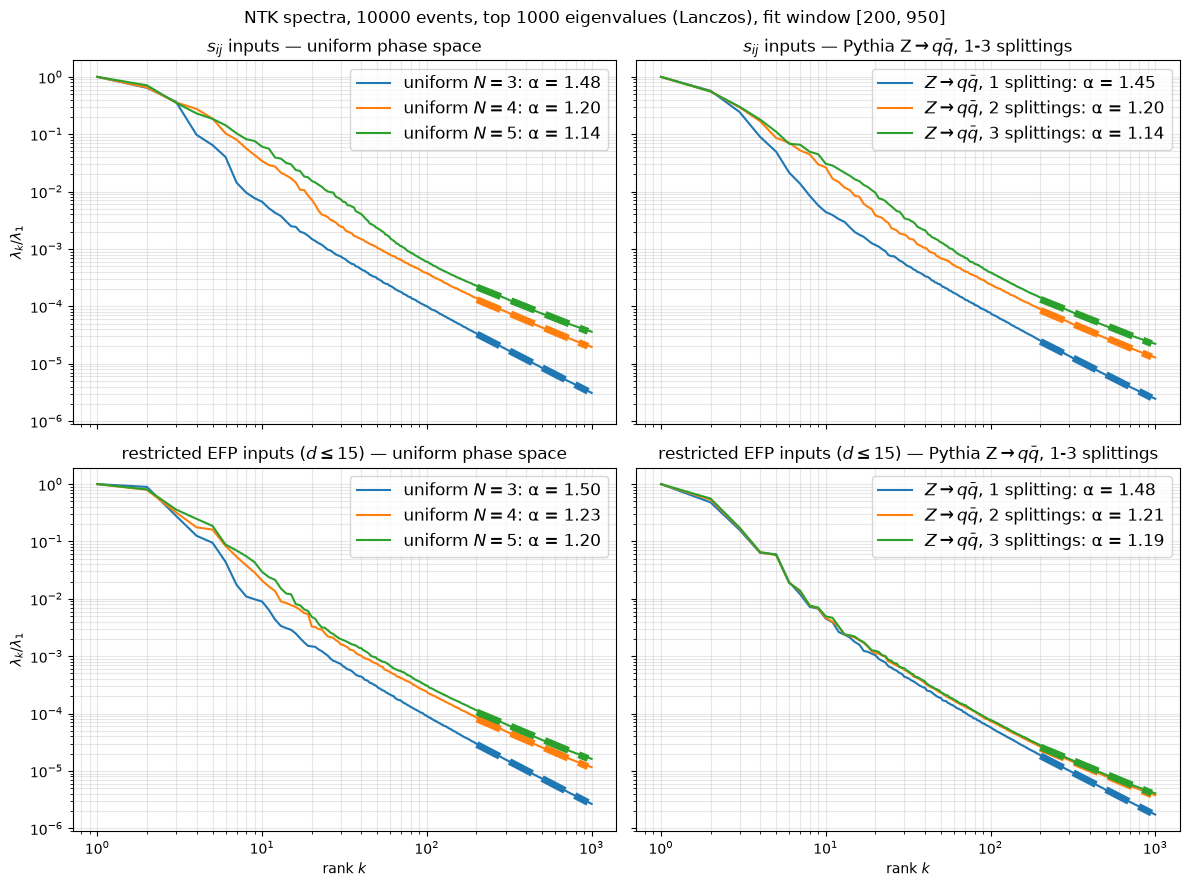

In [36]:
## 2x2: rows = input features, cols = event type; dashed = k^{-(1+1/d)} with d = 3N-7
lo, hi = 200, 950
cols = {'uniform phase space': ['u3', 'u4', 'u5'], r'Pythia Z$\to q\bar q$, 1-3 splittings': ['Z1', 'Z2', 'Z3']}
rows = {r'$s_{ij}$ inputs': NTK_SIJ_eigvals, r'restricted EFP inputs ($d\leq 15$)': NTK_EFP_eigvals}

fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
for i, (rname, L) in enumerate(rows.items()):
    for j, (cname, keys) in enumerate(cols.items()):
        ax = axs[i, j]
        for key in keys:
            lam = L[key]; 
            k = np.arange(1, len(lam) + 1)
            N = int(key[1:]) if key[0] == 'u' else int(key[1:]) + 2; 
            d = 3*N - 7
            a, b = np.polyfit(np.log(k[lo:hi]), np.log(lam[lo:hi]), 1)  
            print(f'{rname[:12]:<12} {key:>3}  d={d:<2d} expect {1 + 1/d:.3f}  got {-a:.3f}')
            # line, = ax.loglog(k, lam/lam[0], label=f'{labels[key]} (d={d}): α = {alpha_eig(lam, lo, hi):.2f}, expect {1 + 1/d:.2f}')
            line, = ax.loglog(k, lam/lam[0], label=f'{labels[key]}: α = {-a:.2f}')
            ax.loglog(k[lo:hi], np.exp(b)*k[lo:hi]**a/lam[0], '--', color=line.get_color(), lw=5)
        ax.set_title(f'{rname} — {cname}'); 
        ax.legend(fontsize=12); 
        ax.grid(True, which='both', alpha=0.3)
for ax in axs[1]: ax.set_xlabel('rank $k$')
for ax in axs[:, 0]: ax.set_ylabel(r'$\lambda_k/\lambda_1$')
fig.suptitle(f'NTK spectra, {n_ev} events, top {k_top} eigenvalues (Lanczos), fit window [{lo}, {hi}]')
fig.tight_layout();

## Compute EFPs, Covariance, Spectrum

Using `measure='ee'` (appropriate for e+e- events), which uses energy fractions z_i = E_i / sum(E_j) and pairwise angles theta_ij computed from the 3-momenta directions.

Input to `batch_compute`: list of (N_particles, 4) arrays with columns (E, px, py, pz).

In [5]:
# ####################
# ## Composite EFPs ##
# ####################
# EFPs_N3_restricted_composite = np.einsum('na,nb->nab', EFPs_N3_restricted, EFPs_N3_restricted).reshape(len(EFPs_N3_restricted), -1)
# EFPs_N5_restricted_composite = np.einsum('na,nb->nab', EFPs_N5_restricted, EFPs_N5_restricted).reshape(len(EFPs_N5_restricted), -1)
# EFPs_N7_restricted_composite = np.einsum('na,nb->nab', EFPs_N7_restricted, EFPs_N7_restricted).reshape(len(EFPs_N7_restricted), -1)
# EFPs_N10_restricted_composite = np.einsum('na,nb->nab', EFPs_N10_restricted, EFPs_N10_restricted).reshape(len(EFPs_N10_restricted), -1)
# print(EFPs_N5_restricted_composite.shape)  

# EFPs_N3_composite = np.einsum('na,nb->nab', EFPs_N3, EFPs_N3).reshape(len(EFPs_N3), -1)
# EFPs_N5_composite = np.einsum('na,nb->nab', EFPs_N5, EFPs_N5).reshape(len(EFPs_N5), -1)
# EFPs_N7_composite = np.einsum('na,nb->nab', EFPs_N7, EFPs_N7).reshape(len(EFPs_N7), -1)
# EFPs_N10_composite = np.einsum('na,nb->nab', EFPs_N10, EFPs_N10).reshape(len(EFPs_N10), -1)
# EFPs_Zqq_composite = np.einsum('na,nb->nab', EFPs_Zqq, EFPs_Zqq).reshape(len(EFPs_Zqq), -1)
# EFPs_Hgg_composite = np.einsum('na,nb->nab', EFPs_Hgg, EFPs_Hgg).reshape(len(EFPs_Hgg), -1)

# EFP_sets_comp = {
#     'u3': EFPs_N3_composite, 'u5': EFPs_N5_composite,
#     'u7': EFPs_N7_composite, 'u10': EFPs_N10_composite,
#     'Z': EFPs_Zqq_composite, 'H': EFPs_Hgg_composite,
# }


# print(EFPs_N5_composite.shape)  


In [ ]:
# # Log
# eps = 1e-10
# log_EFPs_Zqq = np.log(EFPs_Zqq + eps)
# log_EFPs_Hgg = np.log(EFPs_Hgg + eps)
# log_EFPs_N3  = np.log(EFPs_N3  + eps)
# log_EFPs_N5  = np.log(EFPs_N5  + eps)
# log_EFPs_N7  = np.log(EFPs_N7  + eps)
# log_EFPs_N10  = np.log(EFPs_N10  + eps)


In [10]:
labels = {'u3': 'uniform N=3', 'u4': 'uniform N=4', 'u5': 'uniform N=5', 'u7': 'uniform N=7', 'u10': 'uniform N=10',
          'Z': 'Z->qqbar', 'H': 'H->gg',
          'Z1': 'Z->qqbar, 1 splitting', 'Z2': 'Z->qqbar, 2 splittings',
          'Z3': 'Z->qqbar, 3 splittings', 'Z4': 'Z->qqbar, 4 splittings'}


### Covariance Matrix

In [11]:
def cov_eigvals(C):
    """Eigenvalues of a covariance matrix, largest first, negatives clipped to 0."""
    return np.clip(np.linalg.eigvalsh(C)[::-1], 0, None)

covs      = {name: np.cov(X.T) for name, X in EFP_sets.items()}
covs_comp = {name: np.cov(X.T) for name, X in EFP_sets_comp.items()}
print(f"Covariance matrix shape: {covs['Z'].shape}")

Covariance matrix shape: (36, 36)


<!-- ### Eigenspectrum -->

In [12]:
eigvals      = {name: cov_eigvals(C) for name, C in covs.items()}
eigvals_comp = {name: cov_eigvals(C) for name, C in covs_comp.items()}

for name, ev in eigvals.items():
    print(f'{labels[name]}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')
for name, ev in eigvals_comp.items():
    print(f'{labels[name]} (composite): largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')

uniform N=3: largest = 8.0919e+02, smallest = 0.0000e+00
uniform N=4: largest = 5.6595e+02, smallest = 0.0000e+00
uniform N=5: largest = 3.9007e+02, smallest = 0.0000e+00
uniform N=7: largest = 2.0641e+02, smallest = 0.0000e+00
uniform N=10: largest = 1.0144e+02, smallest = 0.0000e+00
Z->qqbar: largest = 5.5481e+02, smallest = 0.0000e+00
H->gg: largest = 6.2032e+02, smallest = 0.0000e+00
Z->qqbar, 1 splitting: largest = 5.0007e+02, smallest = 0.0000e+00
Z->qqbar, 2 splittings: largest = 5.4695e+02, smallest = 0.0000e+00
Z->qqbar, 3 splittings: largest = 5.5317e+02, smallest = 0.0000e+00
Z->qqbar, 4 splittings: largest = 5.5458e+02, smallest = 0.0000e+00
uniform N=3 (composite): largest = 7.6374e+07, smallest = 0.0000e+00
uniform N=5 (composite): largest = 2.7720e+07, smallest = 0.0000e+00
uniform N=7 (composite): largest = 1.2673e+07, smallest = 0.0000e+00
uniform N=10 (composite): largest = 5.4988e+06, smallest = 0.0000e+00
Z->qqbar (composite): largest = 5.7330e+07, smallest = 0.0000

## Plot EFP Spectrum

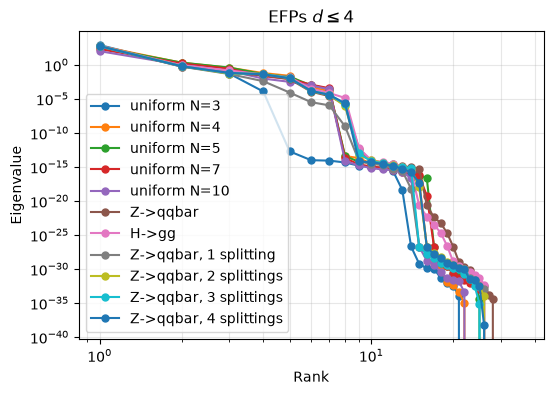

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in eigvals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=10, label=labels[name])
ax.set_xlabel('Rank')
ax.set_ylabel('Eigenvalue')
ax.legend()
ax.set_title(r'EFPs $d\leq 4$')
ax.grid(True, which='both', alpha=0.3)

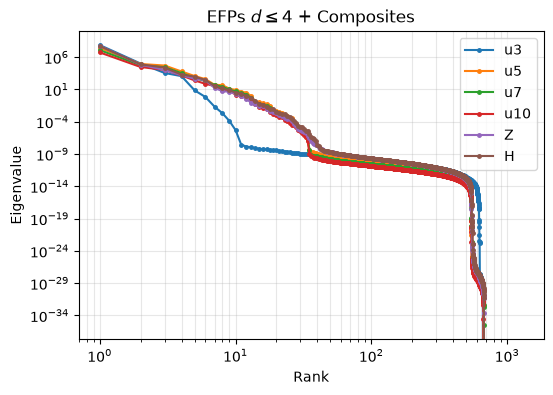

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in eigvals_comp.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=5, label=name)
ax.set_xlabel('Rank'); 
ax.set_ylabel('Eigenvalue')
ax.legend(); 
ax.set_title(r'EFPs $d\leq 4$ + Composites')
ax.grid(True, which='both', alpha=0.3)

Z: window [100,300] has 0 usable pts, skipped
u5: window [100,300] has 0 usable pts, skipped


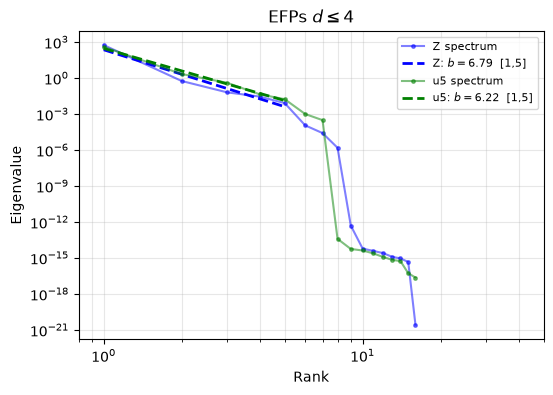

In [16]:
## ==== Plot EFP covariance spectra with power-law fits ==== ## 
fig, ax = plt.subplots(figsize=(6, 4))

lstyles = ['--', ':']
colors  = ['b', 'g']

###### ======== Spectra ========= ######
names = ['Z', 'u5']
fit_min,  fit_max  = 1, 5
fit_min2, fit_max2 = 100, 300
### ==================================== ### 

for (name, c) in zip(names, colors): 
    ev   = eigvals[name]
    idx  = np.arange(1, len(ev) + 1)
    good = ev > ev[0] * 1e-25
    ax.loglog(idx[good], ev[good], '.-', markersize=5, color=c,
              label=f'{name} spectrum', alpha=0.5)

    for (lo, hi), ls in zip([(fit_min, fit_max), (fit_min2, fit_max2)], lstyles): 
        mask = good & (idx >= lo) & (idx <= hi)
        if mask.sum() < 2:
            print(f'{name}: window [{lo},{hi}] has {mask.sum()} usable pts, skipped')
            continue
        slope, log_c = np.polyfit(np.log(idx[mask]), np.log(ev[mask]), 1)
        ax.loglog(idx[mask], np.exp(log_c) * idx[mask]**slope, ls=ls, color=c, lw=2,
                  label=rf'{name}: $b = {-slope:.2f}$  [{lo},{hi}]')

ax.set_xlabel('Rank'); ax.set_ylabel('Eigenvalue')
ax.set_xlim(0.8,5e1)
ax.set_title(r'EFPs $d\leq 4$')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

### NTK 

In [17]:
import importlib, RegressFunctions; importlib.reload(RegressFunctions)
from RegressFunctions import *

In [ ]:
def prep1(Z):   # standardize, append 1, unit-normalize (keeps dimension)
    Z = (Z - Z.mean(0)) / Z.std(0); Z = np.hstack([Z, np.ones((len(Z), 1))])
    return Z / np.linalg.norm(Z, axis=1, keepdims=True)

def alpha(ev, lo=50, hi=1000):
    tail = np.cumsum(ev[::-1])[::-1]; k = np.arange(1, len(tail)+1)
    return 1 - np.polyfit(np.log(k[lo:hi]), np.log(tail[lo:hi]), 1)[0]

def alpha_eig(ev, lo=20, hi=400):
    k = np.arange(1, len(ev)+1)
    return -np.polyfit(np.log(k[lo:hi]), np.log(ev[lo:hi]), 1)[0]

In [ ]:
## Compute NTK EFP spectrum
preproc_EFP_samples = {n: preprocess(X) for n, X in EFP_sets.items()}
NTK_EFP_eigvals = {n: kernel_spectrum(X, kernel="NTK", M=5000) for n, X in preproc_EFP_samples.items()}

In [31]:
## NTK spectra, for EFP and s_ij  ... uniform events
n_ev, k_top = 10_000, 1000
uni = {3: uniform_N3, 4: uniform_N4, 5: uniform_N5, 7: uniform_N7, 10: uniform_N10}
NTK_EFP_eigvals, NTK_SIJ_eigvals = {}, {}
for N, ev in uni.items():
    X = EFP_sets[f'u{N}'][:n_ev]; X = X[:, X.std(0) > 1e-8*X.std(0).max()]      # drop constant (tree) EFPs
    NTK_EFP_eigvals[f'u{N}'] = kernel_spectrum_lanczos(prep1(X), k=k_top, chunk=5000)
    NTK_SIJ_eigvals[f'u{N}'] = kernel_spectrum_lanczos(prep1(pair_inv(ev[:n_ev])), k=k_top, chunk=5000)
    print(N, 'd =', 3*N-7, 'EFP', round(alpha_eig(NTK_EFP_eigvals[f'u{N}'], 200, 950), 2), 
                            's_ij', round(alpha_eig(NTK_SIJ_eigvals[f'u{N}'], 200, 950), 2))

3 d = 2 EFP 1.55 s_ij 1.48
4 d = 5 EFP 1.26 s_ij 1.21
5 d = 8 EFP 1.25 s_ij 1.14
7 d = 14 EFP 1.26 s_ij 1.2
10 d = 23 EFP 1.26 s_ij 1.35


In [ ]:
## NTK spectra, for EFP and s_ij  ... Zqq events
Zsp = {1: Zqq_events_1, 2: Zqq_events_2, 3: Zqq_events_3}          # 3, 4, 5 partons
for s, ev in Zsp.items():
    X = EFP_sets[f'Z{s}'][:n_ev]; X = X[:, X.std(0) > 1e-8*X.std(0).max()]
    NTK_EFP_eigvals[f'Z{s}'] = kernel_spectrum_lanczos(prep1(X), k=k_top, chunk=5000)
    NTK_SIJ_eigvals[f'Z{s}'] = kernel_spectrum_lanczos(prep1(pair_inv(ev[:n_ev])), k=k_top, chunk=5000)
    print(f'{s} split', 'd =', 3*(s+2)-7, 'EFP', round(alpha_eig(NTK_EFP_eigvals[f'Z{s}'], 200, 950), 2),
                                       's_ij', round(alpha_eig(NTK_SIJ_eigvals[f'Z{s}'], 200, 950), 2))

In [ ]:
## Plot 4 panels ... 
lo, hi = 200, 1000
cols = {'uniform': ['u3', 'u4', 'u5', 'u7', 'u10'], r'Z$\to q\bar q$ + splittings': ['Z1', 'Z2', 'Z3']}
rows = {r'$s_{ij}$ inputs': NTK_SIJ_eigvals, r'EFP inputs ($\beta=2,\ d\leq4$)': NTK_EFP_eigvals}
fig, axs = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for i, (rname, L) in enumerate(rows.items()):
    for j, (cname, keys) in enumerate(cols.items()):
        ax = axs[i, j]
        for key in keys:
            lam = L[key]; N = int(key[1:]) if key[0] == 'u' else int(key[1:]) + 2; d = 3*N - 7; k = np.arange(1, len(lam)+1)
            ax.loglog(k, lam/lam[0], label=f'{labels[key]} (d={d}): α = {alpha_eig(lam, lo, hi):.2f}')
            ax.loglog(k[lo:hi], lam[lo]/lam[0]*(k[lo:hi]/lo)**-(1+1/d), 'k--', lw=1.5)
        ax.set_title(f'{rname} — {cname}'); ax.legend(fontsize=8, title='dashed: $k^{-(1+1/d)}$')
for ax in axs[1]: ax.set_xlabel('rank $k$')
for ax in axs[:, 0]: ax.set_ylabel(r'$\lambda_k/\lambda_1$')

(1e-10, 100.0)

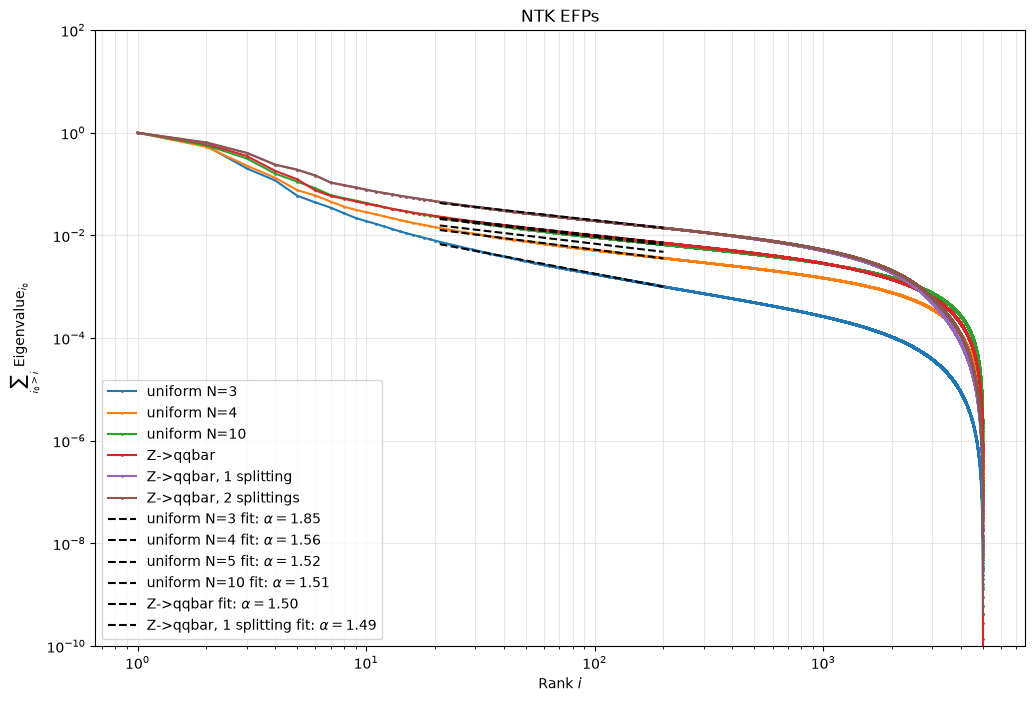

In [ ]:
# # Spectrum Plot
# min_i, max_i = 20, 200
# to_plot = ['u3', 'u4', 'u10', 'Z', 'Z1', 'Z2']

# fig, ax = plt.subplots(figsize=(12, 8))
# for name in to_plot:
#     ev = np.cumsum(NTK_EFP_eigvals[name][::-1])[::-1]   # tail sum, sum_{k'>=k} lambda_k'
#     ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=2, label=labels[name])

# #### ==== #### 
# fit_names = ['u3', 'u4', 'u5', 'u10', 'Z', 'Z1', 'Z2']
# styles = ['--', '--', '--', '--', '--', '--']   # one line style per fit, all in black

# for fit_name, style in zip(fit_names, styles):
#     tail = np.cumsum(NTK_EFP_eigvals[fit_name][::-1])[::-1]
#     k = np.arange(1, len(tail)+1)
#     p = np.polyfit(np.log(k[min_i:max_i]), np.log(tail[min_i:max_i]), 1)
#     ax.loglog(k[min_i:max_i], np.exp(np.polyval(p, np.log(k[min_i:max_i]))), 'k', linestyle=style,
#               label=rf'{labels[fit_name]} fit: $\alpha = {1-p[0]:.2f}$')   # tail slope = 1 - alpha
# #### ==== #### 
# ax.set_xlabel('Rank $i$')
# ax.set_ylabel(r'$\sum_{i_0>i}$ Eigenvalue$_{i_0}$')
# ax.legend()
# ax.set_title(r'NTK EFPs')
# ax.grid(True, which='both', alpha=0.3)
# ax.set_ylim(1e-10, 1e2)

In [ ]:
# ## feed inv masses instead of EFPs ... 

# def prep1(Z):   # standardize, append 1, unit-normalize (keeps dimension)
#     Z = (Z - Z.mean(0)) / Z.std(0); Z = np.hstack([Z, np.ones((len(Z), 1))])
#     return Z / np.linalg.norm(Z, axis=1, keepdims=True)

# def alpha(ev, lo=50, hi=1000):
#     tail = np.cumsum(ev[::-1])[::-1]; k = np.arange(1, len(tail)+1)
#     return 1 - np.polyfit(np.log(k[lo:hi]), np.log(tail[lo:hi]), 1)[0]

# def alpha_eig(ev, lo=20, hi=400):
#     k = np.arange(1, len(ev)+1)
#     return -np.polyfit(np.log(k[lo:hi]), np.log(ev[lo:hi]), 1)[0]

# # lams = {}
# # for N in [3, 4, 5]:
# #     ev = gen_massless_phase_space(50_000, N, energy=1.0)
# #     lams[N] = kernel_spectrum(prep1(pair_inv(ev)), kernel="NTK", M=10_000)
# #     print(N, 'expect', 1 + 1/(3*N-7), 'got', round(alpha(lams[N], 100, 500), 2))

# NTK_SIJ_eigvals = {}
# n_ev, k_top = 10_000, 1000        
# for N in [3, 4, 5]:
#     ev = gen_massless_phase_space(n_ev, N, energy=1.0)
#     NTK_SIJ_eigvals[f'u{N}'] = kernel_spectrum_lanczos(prep1(pair_inv(ev)), k=k_top, chunk=5000)
#     print(N, 'expect', round(1 + 1/(3*N-7), 3), 'got', round(alpha_eig(NTK_SIJ_eigvals[f'u{N}'], 300, min(1000, k_top-50)), 2))

3 expect 1.5 got 1.47
4 expect 1.2 got 1.17
5 expect 1.125 got 1.11


Text(0, 0.5, '$\\lambda_k$')

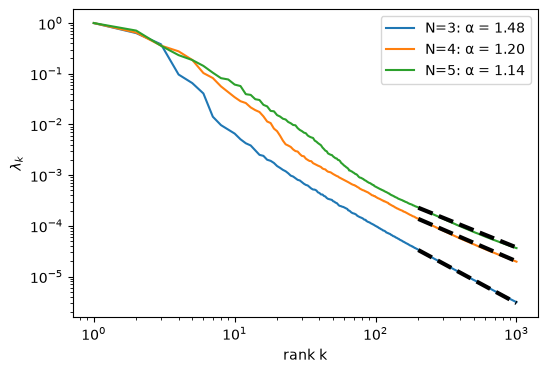

In [23]:
lo, hi = 200, 1000
fig, ax = plt.subplots(figsize=(6, 4))
for key, lam in NTK_SIJ_eigvals.items():
    N = int(key[1:])
    k = np.arange(1, len(lam)+1)
    ax.loglog(k, lam/lam[0], label=f'N={N}: α = {alpha_eig(lam, lo, hi):.2f}')
    ax.loglog(k[lo:hi], lam[lo]/lam[0]*(k[lo:hi]/lo)**-(1+1/(3*N-7)), 'k--', lw=3)
ax.legend(); ax.set_xlabel('rank k'); ax.set_ylabel(r'$\lambda_k$')

In [26]:
NTK_EFP_u = {f'u{N}': kernel_spectrum_lanczos(prep1(EFP_sets[f'u{N}'][:n_ev][:, EFP_sets[f'u{N}'].std(0) > 1e-8]), k=k_top, chunk=5000) for N in [3, 4, 5]}
for key, lam in NTK_EFP_u.items(): print(key, round(alpha_eig(lam, 20, 200), 2), round(alpha_eig(lam, 200, 1000), 2))

u3 1.77 1.55
u4 1.57 1.25
u5 1.53 1.25


Text(0, 0.5, '$\\lambda_k/\\lambda_1$')

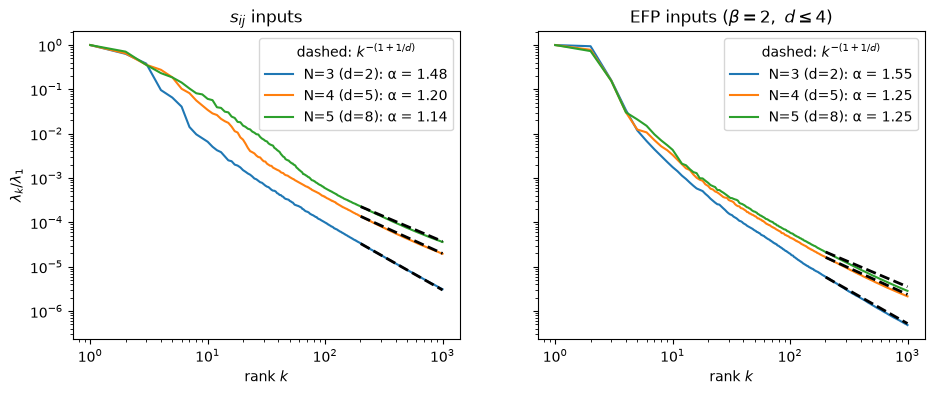

In [30]:
lo, hi = 200, 1000
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, title, L in zip(axs, [r'$s_{ij}$ inputs', r'EFP inputs ($\beta=2,\ d\leq4$)'], [NTK_SIJ_eigvals, NTK_EFP_u]):
    for key, lam in L.items():
        N = int(key[1:]); d = 3*N - 7; k = np.arange(1, len(lam)+1)
        ax.loglog(k, lam/lam[0], label=f'N={N} (d={d}): α = {alpha_eig(lam, lo, hi):.2f}')
        ax.loglog(k[lo:hi], lam[lo]/lam[0]*(k[lo:hi]/lo)**-(1+1/d), 'k--', lw=2)
    ax.set_title(title); ax.set_xlabel('rank $k$'); ax.legend(title='dashed: $k^{-(1+1/d)}$')
axs[0].set_ylabel(r'$\lambda_k/\lambda_1$')

Text(0, 0.5, '$\\lambda_k/\\lambda_1$')

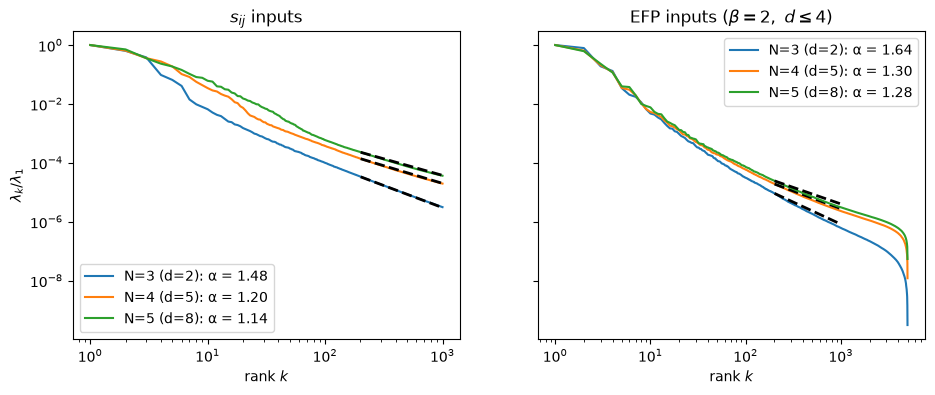

In [25]:
### Compare to EFPs

lo, hi = 200, 1000
fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, title, L in zip(axs, [r'$s_{ij}$ inputs', r'EFP inputs ($\beta=2,\ d\leq4$)'], [NTK_SIJ_eigvals, NTK_EFP_eigvals]):
    for key in ['u3', 'u4', 'u5']:
        lam, N = L[key], int(key[1:]); 
        k = np.arange(1, len(lam)+1); 
        d = 3*N - 7
        ax.loglog(k, lam/lam[0], label=f'N={N} (d={d}): α = {alpha_eig(lam, lo, hi):.2f}')
        ax.loglog(k[lo:hi], lam[lo]/lam[0]*(k[lo:hi]/lo)**-(1+1/d), 'k--', lw=2)
    ax.set_title(title); ax.set_xlabel('rank $k$'); 
    ax.legend()
axs[0].set_ylabel(r'$\lambda_k/\lambda_1$')

## Compute Q-vectors, Covariance, Spectrum

In [20]:
def qvec_one(event, nq=64, eps=1e-12):
    E, p = event[:, 0], event[:, 1:4]
    pn = np.linalg.norm(p, axis=1)
    keep = pn > eps
    E, p, pn = E[keep], p[keep], pn[keep]
    z = E / E.sum()
    cos = np.clip((p @ p.T) / np.outer(pn, pn), -1.0, 1.0)
    theta = np.arccos(cos)
    np.fill_diagonal(theta, 0.0)                        # i=j pairs exactly at 0, not 3e-8 from roundoff
    theta, w = theta.ravel(), np.outer(z, z).ravel()    # all ordered pairs, i=j included; w sums to 1
    order = np.argsort(theta)
    theta, cw = theta[order], np.cumsum(w[order])
    cw /= cw[-1]                                        # kill roundoff so F(pi) = 1 exactly
    u = (np.arange(nq) + 0.5) / nq
    return theta[np.searchsorted(cw, u, side='left')]   # min{theta : F(theta) >= u_k}

def qvec(events, nq=64, eps=1e-12):
    Q = np.array([qvec_one(e, nq, eps) for e in events])
    assert Q.shape == (len(events), nq) and Q.min() >= 0 and Q.max() <= np.pi and np.all(np.diff(Q, axis=1) >= 0)
    return Q


Qs_N3 = qvec(uniform_N3);   print('uniform N=3 done')
Qs_N5 = qvec(uniform_N5);   print('uniform N=5 done')
Qs_N7 = qvec(uniform_N7);   print('uniform N=7 done')
Qs_N10 = qvec(uniform_N10);   print('uniform N=10 done')

Qs_Zqq = qvec(Zqq_events); print('Z->qqbar done')
Qs_Hgg = qvec(Hgg_events); print('H->gg done')

Q_samples = [('Z->qqbar', Qs_Zqq), ('H->gg', Qs_Hgg),
           ('uniform N=3', Qs_N3), ('uniform N=5', Qs_N5),
           ('uniform N=7', Qs_N7), ('uniform N=10', Qs_N10)]


uniform N=3 done
uniform N=5 done
uniform N=7 done
uniform N=10 done
Z->qqbar done
H->gg done


In [21]:
Qs_cov_u3 = np.cov(Qs_N3.T)
Qs_cov_u5 = np.cov(Qs_N5.T)
Qs_cov_u7 = np.cov(Qs_N7.T)
Qs_cov_u10 = np.cov(Qs_N10.T)
Qs_cov_Z = np.cov(Qs_Zqq.T) 
Qs_cov_H = np.cov(Qs_Hgg.T)

print(f'Covariance matrix shape: {Qs_cov_u3.shape}')

Covariance matrix shape: (64, 64)


In [22]:
Q_covs = [('Z->qqbar', Qs_cov_Z), ('H->gg', Qs_cov_H),
           ('uniform N=3', Qs_cov_u3), ('uniform N=5', Qs_cov_u5),
           ('uniform N=7', Qs_cov_u7), ('uniform N=10', Qs_cov_u10)]

eigvals, eigvals_comp = {}, {}
for name, cov in Q_covs:
    ev = np.clip(np.sort(np.linalg.eigvalsh(cov))[::-1], 0, None)
    eigvals[name] = ev
    print(f'{name}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')

Z->qqbar: largest = 3.3308e+00, smallest = 0.0000e+00
H->gg: largest = 2.9178e+00, smallest = 0.0000e+00
uniform N=3: largest = 5.0585e+00, smallest = 0.0000e+00
uniform N=5: largest = 1.9347e+00, smallest = 0.0000e+00
uniform N=7: largest = 9.9561e-01, smallest = 0.0000e+00
uniform N=10: largest = 4.8816e-01, smallest = 0.0000e+00


## Plot Q-vec Spectrum

(1e-25, 100.0)

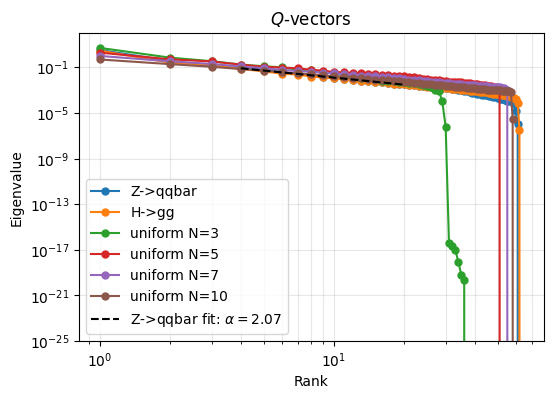

In [56]:
# Spectrum Plot
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in eigvals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=10, label=name)
### FIT ### 
k = np.arange(1, len(eigvals['Z->qqbar'])+1); p = np.polyfit(np.log(k[3:20]), np.log(eigvals['Z->qqbar'][3:20]), 1)   
ax.loglog(k[3:20], np.exp(np.polyval(p, np.log(k[3:20]))), 'k--', label=rf'Z->qqbar fit: $\alpha = {-p[0]:.2f}$')     
ax.set_xlabel('Rank'); 
ax.set_ylabel('Eigenvalue')
ax.legend(); 
ax.set_title(r'$Q$-vectors')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(1e-25, 1e2)

### NTK

In [62]:
## Compute NTK Q spectrum
preproc_Q_samples = {n: preprocess(Q) for n, Q in Q_samples} 
NTK_Q_eigvals = {n: kernel_spectrum(Q, kernel="NTK", M=6000) for n, Q in preproc_Q_samples.items()}  

(1e-10, 100.0)

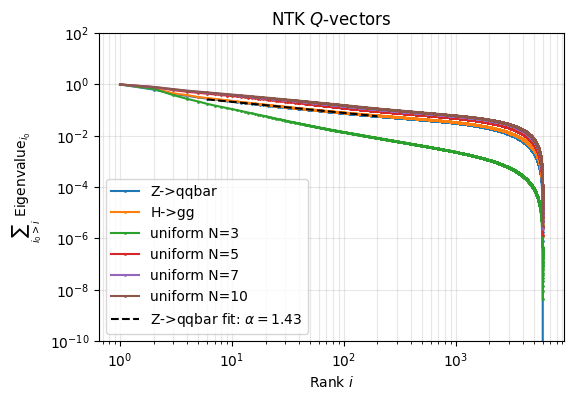

In [63]:
# Spectrum Plot
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in NTK_Q_eigvals.items():
    ev = np.cumsum(ev[::-1])[::-1]   # NEW: tail sum, sum_{k'>=k} lambda_k'
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=2, label=name)
tail = np.cumsum(NTK_Q_eigvals['Z->qqbar'][::-1])[::-1]; k = np.arange(1, len(tail)+1); p = np.polyfit(np.log(k[5:200]), np.log(tail[5:200]), 1)   # NEW
ax.loglog(k[5:200], np.exp(np.polyval(p, np.log(k[5:200]))), 'k--', label=rf'Z->qqbar fit: $\alpha = {1-p[0]:.2f}$')                                # NEW: tail slope = 1 - alpha
ax.set_xlabel('Rank $i$'); 
ax.set_ylabel(r'$\sum_{i_0>i}$ Eigenvalue$_{i_0}$')
ax.legend(); 
ax.set_title(r'NTK $Q$-vectors')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(1e-10, 1e2)

## Define, Plot Thrust 
Thrust is IRC-safe and well-approximated by low-d EFPs, so the irreducible floor should be near zero.

In [77]:
thrust_samples = {
    'Z->qqbar':    Zqq_events,
    'H->gg':       Hgg_events,
    'uniform N=3': uniform_N3,
    'uniform N=5': uniform_N5,
    'uniform N=7': uniform_N7,
    'uniform N=10': uniform_N10,
}

thrusts = {}
for name, events in thrust_samples.items():
    t = np.array([compute_thrust(e) for e in events])
    thrusts[name] = t
    print(f'{name}: mean thrust = {np.mean(t):.4f} +/- {np.std(t):.4f}')


Z->qqbar: mean thrust = 0.9351 +/- 0.0631
H->gg: mean thrust = 0.8612 +/- 0.0826
uniform N=3: mean thrust = 0.8890 +/- 0.0786
uniform N=5: mean thrust = 0.7700 +/- 0.0884
uniform N=7: mean thrust = 0.7222 +/- 0.0781
uniform N=10: mean thrust = 0.6857 +/- 0.0655


Text(0.5, 0, 'EFP Value')

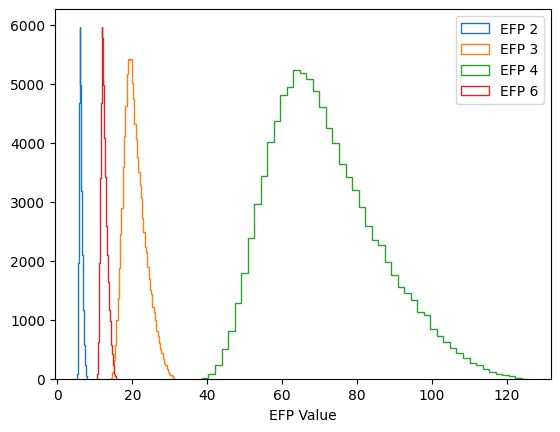

In [78]:
## Plot features ...  
plt.hist(EFPs_N5[:, 2], bins=50, histtype='step', label='EFP 2')
plt.hist(EFPs_N5[:, 3], bins=50, histtype='step', label='EFP 3')
plt.hist(EFPs_N5[:, 4], bins=50, histtype='step', label='EFP 4')
plt.hist(EFPs_N5[:, 6], bins=50, histtype='step', label='EFP 6')
plt.legend(); plt.xlabel('EFP Value')

Text(0.5, 0, 'Thrust')

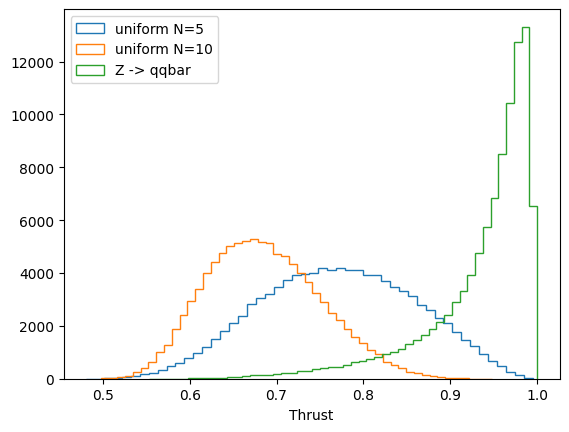

In [79]:
## Plot targets ... 
plt.hist(thrusts['uniform N=5'], bins=50, histtype='step', label='uniform N=5');
plt.hist(thrusts['uniform N=10'], bins=50, histtype='step', label='uniform N=10');
plt.hist(thrusts['Z->qqbar'], bins=50, histtype='step', label='Z -> qqbar');
plt.legend(); plt.xlabel("Thrust")

In [80]:
def kernel_eig(X, M=5000, seed=0):
    """kernel_spectrum with eigenvectors: (eigvals desc, eigvecs as columns, subsample idx). Same idx as kernel_spectrum."""
    idx = np.random.default_rng(seed).choice(len(X), min(M, len(X)), replace=False)
    Xs = torch.as_tensor(np.asarray(X)[idx], dtype=torch.float64)
    lam, U = np.linalg.eigh((ntk(Xs, Xs) / len(idx)).numpy())
    return lam[::-1], U[:, ::-1], idx


# compute once (slow cell)
NTKeig = {name: kernel_eig(Q, M=2000) for name, Q in Qsamples}   # name -> (lam, U, idx)

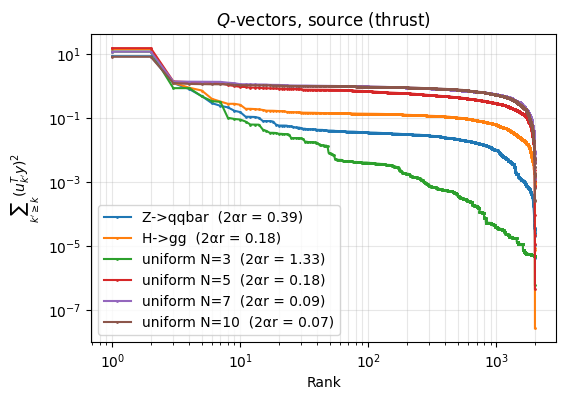

In [81]:
# Source Plot (RHS of Fig. 1, target = thrust)
fig, ax = plt.subplots(figsize=(6, 4))
for name, (lam, U, idx) in NTKeig.items():
    y = thrusts[name][idx]; y = y - y.mean()                       # centered target on the same events as K
    tail = np.cumsum(((U.T @ y)**2)[::-1])[::-1]                   # sum_{k'>=k} (u_k'^T y)^2
    k = np.arange(1, len(tail)+1)
    s = -np.polyfit(np.log(k[3:300]), np.log(tail[3:300]), 1)[0]  # = 2*alpha*r
    ax.loglog(k, tail, '.-', markersize=2, label=f'{name}  (2αr = {s:.2f})')

ax.set_xlabel('Rank')
ax.set_ylabel(r'$\sum_{k^\prime \geq k} (u_{k^\prime}^{T} y)^2$')
ax.legend()
ax.set_title(r'$Q$-vectors, source (thrust)')
ax.grid(True, which='both', alpha=0.3)

## NTK KRR: Qs → Thrust

In [25]:
import importlib, RegressFunctions
importlib.reload(RegressFunctions)
from RegressFunctions import *

In [52]:
Ps = np.unique(np.round(np.logspace(0, 3.5, 10)).astype(int))   

In [54]:
## train on NTK_Q_eigvals
λs = [1e-10]
n_reps = lambda P: max(int(500 / P), 5)
NTK_losses_Z, NTK_losses_N3, NTK_losses_N5, NTK_losses_N10 = {}, {}, {}, {}
for λ in λs: 
    NTK_losses_Z[λ]  = run_regression_sweep(Qs_Zqq, thrusts['Z->qqbar'],  Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=True, center=True, scale=True, kern="NTK")
    # losses_N3[r] = run_torch_regression(EFPs_N3_composite,  thrusts['uniform N=3'], train_sizes_t, r=r)
    NTK_losses_N5[λ] = run_regression_sweep(Qs_N5,  thrusts['uniform N=5'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=True, center=True, scale=True, kern="NTK")
    NTK_losses_N10[λ] = run_regression_sweep(Qs_N10,  thrusts['uniform N=10'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                         w_true=None, filter_zero_var=True, center=True, scale=True, kern="NTK")

(80000, 61) (20000, 61) 51.2 GB per train Gram
       1  |  0.002783
       2  |  0.002125
       6  |  0.001302
      15  |  0.000440
      36  |  0.000381
      88  |  0.000224
     215  |  0.000206
     527  |  0.000146
    1292  |  0.000119
    3162  |  0.000097
(80000, 51) (20000, 51) 51.2 GB per train Gram
       1  |  0.006037
       2  |  0.004820
       6  |  0.002102
      15  |  0.001040
      36  |  0.000762
      88  |  0.000611
     215  |  0.000557
     527  |  0.000432
    1292  |  0.000366
    3162  |  0.000317
(80000, 57) (20000, 57) 51.2 GB per train Gram
       1  |  0.003512
       2  |  0.003002
       6  |  0.001462
      15  |  0.000838
      36  |  0.000758
      88  |  0.000740
     215  |  0.000706
     527  |  0.000668
    1292  |  0.000627
    3162  |  0.000591


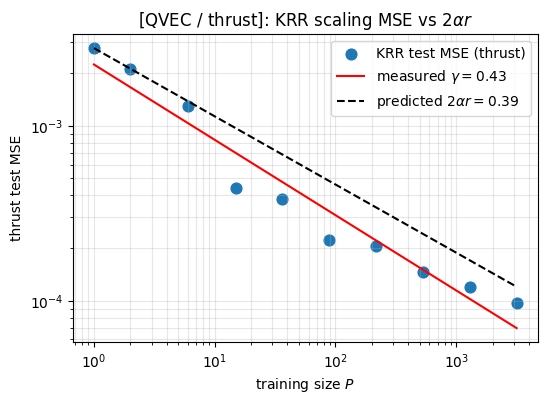

In [57]:
# Fig. 4: KRR test MSE vs n, Z->qqbar, thrust
losses, stds = NTK_losses_Z[λs[0]]
P = np.array(Ps); m = np.array(losses)
gamma = -np.polyfit(np.log(P), np.log(m), 1)[0]
two_ar = 0.39                                                   # from the source-plot fit above
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(P, m, s=60, label='KRR test MSE (thrust)')
ax.loglog(P, np.exp(np.polyval(np.polyfit(np.log(P), np.log(m), 1), np.log(P))), 'r-', label=rf'measured $\gamma = {gamma:.2f}$')
ax.loglog(P, m[0]*(P/P[0])**(-two_ar), 'k--', label=rf'predicted $2\alpha r = {two_ar:.2f}$')
ax.set_xlabel('training size $P$'); ax.set_ylabel('thrust test MSE')
ax.set_title(r'[QVEC / thrust]: KRR scaling MSE vs $2\alpha r$'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

## NTK KRR: EFPs → Thrust

In [24]:
NTK_spec_Zqq = kernel_spectrum(EFPs_Zqq,  kernel="NTK")
NTK_spec_uN5 = kernel_spectrum(EFPs_N5,   kernel="NTK")
NTK_spec_uN10 = kernel_spectrum(EFPs_N10, kernel="NTK")

Text(0, 0.5, '$\\lambda_k$')

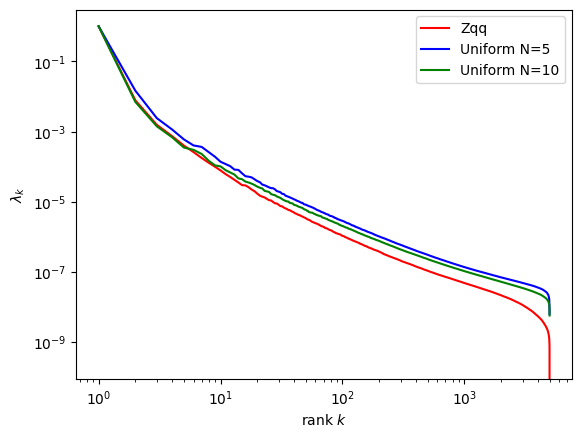

In [25]:
## Plot NTK Spectrum
i = np.arange(1, len(NTK_spec_Zqq)+1)
plt.loglog(i, NTK_spec_Zqq/NTK_spec_Zqq[0], ms=2, color='r', linestyle='-'); 
plt.loglog(i, NTK_spec_uN5/NTK_spec_uN5[0], ms=2, color='b', linestyle='-'); 
plt.loglog(i, NTK_spec_uN10/NTK_spec_uN10[0], ms=2, color='g', linestyle='-'); 
plt.legend(['Zqq', 'Uniform N=5', 'Uniform N=10'])
plt.xlabel(r'rank $k$'); plt.ylabel(r'$\lambda_k$')

In [ ]:
## Sum_k \lambda_k 
## Plot NTK Spectrum
i = np.arange(1, len(NTK_spec_Zqq)+1)
plt.loglog(i, NTK_spec_Zqq/NTK_spec_Zqq[0], ms=2, color='r', linestyle='-'); 
plt.loglog(i, NTK_spec_uN5/NTK_spec_uN5[0], ms=2, color='b', linestyle='-'); 
plt.loglog(i, NTK_spec_uN10/NTK_spec_uN10[0], ms=2, color='g', linestyle='-'); 
plt.legend(['Zqq', 'Uniform N=5', 'Uniform N=10'])
plt.xlabel(r'rank $k$'); plt.ylabel(r'$\lambda_k$')